## Bài tập 1: groceries.csv

Install libraries

In [ ]:
%pip install -q mlxtend pandas scikit-learn numpy matplotlib seaborn openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Import libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from collections import Counter
from itertools import combinations
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori as mlxtend_apriori
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

Import data

In [3]:
CSV_PATH = "groceries.csv"

Câu 1: Đọc groceries.csv dataset và chuyển thành danh sách các giao dịch. In ra số lượng
giao dịch và số lượng item.

In [4]:
transactions = []
with open(CSV_PATH, "r", encoding="utf-8") as f:
    for line in f:
        items = [x.strip() for x in line.strip().split(",") if x.strip()]
        transactions.append(items)

num_transactions = len(transactions)
total_item_occurrences = sum(len(t) for t in transactions)
print(f"Số giao dịch: {num_transactions}")
print(f"Tổng số lượt item (tổng phần tử trong mọi giao dịch): {total_item_occurrences}")

Số giao dịch: 9835
Tổng số lượt item (tổng phần tử trong mọi giao dịch): 43367


Câu 2: Tính số giao dịch, số item khác nhau và top 10 item xuất hiện nhiều nhất.

In [5]:
num_transactions = len(transactions)
all_items = [item for t in transactions for item in t]
unique_items = set(all_items)
counter = Counter(all_items)

print(f"Số giao dịch: {num_transactions}")
print(f"Số item khác nhau: {len(unique_items)}")
print("Top 10 item xuất hiện nhiều nhất:")
for item, cnt in counter.most_common(10):
    print(f"  {item}: {cnt}")

Số giao dịch: 9835
Số item khác nhau: 169
Top 10 item xuất hiện nhiều nhất:
  whole milk: 2513
  other vegetables: 1903
  rolls/buns: 1809
  soda: 1715
  yogurt: 1372
  bottled water: 1087
  root vegetables: 1072
  tropical fruit: 1032
  shopping bags: 969
  sausage: 924


Câu 3: Viết code cài đặt tính support của từng 1-itemset.

In [6]:
support_1 = {}
for item in unique_items:
    count = sum(1 for t in transactions if item in t)
    support_1[item] = count / num_transactions

# Hiển thị vài phần tử (file có nhiều item)
print(f"Số 1-itemset: {len(support_1)}")
print("Ví dụ 5 item đầu (theo thứ tự bảng chữ cái):")
for item in sorted(support_1)[:5]:
    print(f"  {item!r}: support = {support_1[item]:.4f}")

Số 1-itemset: 169
Ví dụ 5 item đầu (theo thứ tự bảng chữ cái):
  'Instant food products': support = 0.0080
  'UHT-milk': support = 0.0335
  'abrasive cleaner': support = 0.0036
  'artif. sweetener': support = 0.0033
  'baby cosmetics': support = 0.0006


Câu 4: Frequent 1-itemsets (L1) với min_support cho trước

In [8]:
min_support = 0.01
L1 = {item: sup for item, sup in support_1.items() if sup >= min_support}
print(f"min_support = {min_support}")
print(f"|L1| = {len(L1)}")

min_support = 0.01
|L1| = 88


Câu 5: Candidate 2-itemsets (C2) và frequent 2-itemsets (L2)

In [9]:
items_L1 = list(L1.keys())
C2 = list(combinations(items_L1, 2))
support_2 = {}
for pair in C2:
    count = sum(1 for t in transactions if set(pair).issubset(t))
    support_2[pair] = count / num_transactions

L2 = {pair: sup for pair, sup in support_2.items() if sup >= min_support}
print(f"|C2| = {len(C2)}")
print(f"|L2| = {len(L2)}")

|C2| = 3828
|L2| = 213


Câu 6: Không sử dụng thư viện mlxtend, cài đặt Apriori bằng Python. Viết hàm có dạng:
apriori(transactions, min_support)

- Hàm `apriori(transactions, min_support)` trả về danh sách `[L1, L2, ...]` (mỗi `Lk` là `dict`: itemset → support).  
- Tham số tùy chọn `verbose=True` (chỉ dùng ở Câu 7) để in các tập ứng viên và tập phổ biến từng bước.

In [10]:
def apriori(transactions, min_support, *, verbose=False):
    """Trả về [L1, L2, ...]; mỗi Lk là dict frozenset -> support. verbose=True: in C_k, L_k."""
    n = len(transactions)
    trans_sets = [set(t) for t in transactions]

    def sup_count(itemset):
        s = set(itemset)
        return sum(1 for t in trans_sets if s <= t) / n

    unique = sorted(set(x for t in transactions for x in t))
    C1 = {frozenset([i]): sup_count(frozenset([i])) for i in unique}
    L1 = {k: v for k, v in C1.items() if v >= min_support}

    if verbose:
        print("C1")
        for it, s in sorted(C1.items(), key=lambda x: sorted(x[0])):
            print(tuple(sorted(it)), s)
        print("\nL1")
        for it, s in sorted(L1.items(), key=lambda x: sorted(x[0])):
            print(tuple(sorted(it)), s)
        print()

    L_all = [L1]
    L_prev = L1
    k = 1

    while L_prev:
        keys = sorted(L_prev.keys(), key=lambda x: sorted(x))
        candidates = []
        for i in range(len(keys)):
            for j in range(i + 1, len(keys)):
                a = sorted(keys[i])
                b = sorted(keys[j])
                if len(a) != k or len(b) != k:
                    continue
                if a[: k - 1] == b[: k - 1] and a[-1] < b[-1]:
                    new = frozenset(a + [b[-1]])
                    if all(frozenset(sub) in L_prev for sub in combinations(sorted(new), k)):
                        if new not in candidates:
                            candidates.append(new)
        if not candidates:
            break

        Ck = {c: sup_count(c) for c in candidates}
        if verbose:
            print(f"C{k + 1}")
            for it, s in sorted(Ck.items(), key=lambda x: sorted(x[0])):
                print(tuple(sorted(it)), s)
            print()

        Lk = {c: v for c, v in Ck.items() if v >= min_support}
        if verbose:
            print(f"L{k + 1}")
            for it, s in sorted(Lk.items(), key=lambda x: sorted(x[0])):
                print(tuple(sorted(it)), s)
            print()

        if not Lk:
            break
        L_all.append(Lk)
        L_prev = Lk
        k += 1

    return L_all

Câu 7: In ra các bước trung gian C1, L1, C2, L2, ... của Apriori.

In [11]:
# In C1, L1, C2, L2, ...
L = apriori(transactions, 0.01, verbose=True)

# Gợi ý đề bài
for i, l in enumerate(L):
    print(f"L{i+1}")
    for item, sup in l.items():
        print(item, sup)
    print()

C1
('Instant food products',) 0.008032536858159633
('UHT-milk',) 0.03345195729537367
('abrasive cleaner',) 0.0035587188612099642
('artif. sweetener',) 0.003253685815963396
('baby cosmetics',) 0.0006100660904931368
('baby food',) 0.00010167768174885612
('bags',) 0.0004067107269954245
('baking powder',) 0.017691916624300967
('bathroom cleaner',) 0.0027452974072191155
('beef',) 0.05246568378240976
('berries',) 0.033248601931875954
('beverages',) 0.026029486527707167
('bottled beer',) 0.08052872394509406
('bottled water',) 0.11052364006100661
('brandy',) 0.004168784951703101
('brown bread',) 0.06487036095577021
('butter',) 0.05541433655312659
('butter milk',) 0.027961362480935434
('cake bar',) 0.013218098627351297
('candles',) 0.008947635993899338
('candy',) 0.0298932384341637
('canned beer',) 0.07768174885612608
('canned fish',) 0.015048296898830707
('canned fruit',) 0.003253685815963396
('canned vegetables',) 0.010777834265378749
('cat food',) 0.023284189120488054
('cereals',) 0.00569395

Câu 8: Dùng TransactionEncoder để one-hot encode dữ liệu.

In [12]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)
print(df.shape)
df.head()

(9835, 169)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


Câu 9: Dùng thư viện mlxtend chạy Apriori.

In [13]:
frequent_itemsets = mlxtend_apriori(df, min_support=0.01, use_colnames=True)
print(frequent_itemsets.head())
print(f"Tổng số frequent itemsets (Apriori): {len(frequent_itemsets)}")

    support                    itemsets
0  0.033452       frozenset({UHT-milk})
1  0.017692  frozenset({baking powder})
2  0.052466           frozenset({beef})
3  0.033249        frozenset({berries})
4  0.026029      frozenset({beverages})
Tổng số frequent itemsets (Apriori): 333


Câu 10: Dùng thư viện mlxtend chạy FP-Growth.

In [14]:
fp_itemsets = fpgrowth(df, min_support=0.01, use_colnames=True)
print(fp_itemsets.head())
print(f"Tổng số frequent itemsets (FP-Growth): {len(fp_itemsets)}")

    support                          itemsets
0  0.082766         frozenset({citrus fruit})
1  0.058566            frozenset({margarine})
2  0.017692  frozenset({semi-finished bread})
3  0.139502               frozenset({yogurt})
4  0.104931       frozenset({tropical fruit})
Tổng số frequent itemsets (FP-Growth): 333


Câu 11: Dùng thư viện để lấy ra association rules từ frequent itemsets.

In [15]:
rules = association_rules(fp_itemsets, metric="confidence", min_threshold=0.2)
print(f"Số luật (min_confidence=0.2): {len(rules)}")
rules.head()

Số luật (min_confidence=0.2): 234


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({citrus fruit}),frozenset({whole milk}),0.082766,0.255516,0.030503,0.368550,1.442377,1.0,0.009355,1.179008,0.334375,0.099108,0.151829,0.243965
1,frozenset({citrus fruit}),frozenset({yogurt}),0.082766,0.139502,0.021657,0.261671,1.875752,1.0,0.010111,1.165467,0.509009,0.107957,0.141975,0.208459
2,frozenset({citrus fruit}),frozenset({tropical fruit}),0.082766,0.104931,0.019929,0.240786,2.294702,1.0,0.011244,1.178942,0.615125,0.118788,0.151782,0.215354
3,frozenset({citrus fruit}),frozenset({other vegetables}),0.082766,0.193493,0.028876,0.348894,1.803140,1.0,0.012862,1.238674,0.485603,0.116728,0.192685,0.249066
4,frozenset({citrus fruit}),frozenset({root vegetables}),0.082766,0.108998,0.017692,0.213759,1.961121,1.0,0.008671,1.133243,0.534310,0.101636,0.117576,0.188036


Câu 12: Lọc top 10 luật theo confidence.

In [16]:
rules_sorted = rules.sort_values(by="confidence", ascending=False)
rules_sorted.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
11,"frozenset({root vegetables, citrus fruit})",frozenset({other vegetables}),0.017692,0.193493,0.010371,0.586207,3.029608,1.0,0.006948,1.949059,0.681990,0.051646,0.486932,0.319903
51,"frozenset({root vegetables, tropical fruit})",frozenset({other vegetables}),0.021047,0.193493,0.012303,0.584541,3.020999,1.0,0.008231,1.941244,0.683367,0.060835,0.484867,0.324062
108,"frozenset({yogurt, curd})",frozenset({whole milk}),0.017285,0.255516,0.010066,0.582353,2.279125,1.0,0.005649,1.782567,0.571107,0.038313,0.439011,0.310874
77,"frozenset({butter, other vegetables})",frozenset({whole milk}),0.020031,0.255516,0.011490,0.573604,2.244885,1.0,0.006371,1.745992,0.565878,0.043512,0.427260,0.309285
54,"frozenset({root vegetables, tropical fruit})",frozenset({whole milk}),0.021047,0.255516,0.011998,0.570048,2.230969,1.0,0.006620,1.731553,0.563627,0.045350,0.422484,0.308502
161,"frozenset({root vegetables, yogurt})",frozenset({whole milk}),0.025826,0.255516,0.014540,0.562992,2.203354,1.0,0.007941,1.703594,0.560625,0.054497,0.413006,0.309948
221,"frozenset({other vegetables, domestic eggs})",frozenset({whole milk}),0.022267,0.255516,0.012303,0.552511,2.162336,1.0,0.006613,1.663694,0.549779,0.046342,0.398928,0.300331
200,"frozenset({yogurt, whipped/sour cream})",frozenset({whole milk}),0.020742,0.255516,0.010880,0.524510,2.052747,1.0,0.005580,1.565719,0.523711,0.040996,0.361316,0.283544
158,"frozenset({root vegetables, rolls/buns})",frozenset({whole milk}),0.024301,0.255516,0.012710,0.523013,2.046888,1.0,0.006500,1.560804,0.524192,0.047583,0.359305,0.286377
63,"frozenset({other vegetables, pip fruit})",frozenset({whole milk}),0.026131,0.255516,0.013523,0.517510,2.025351,1.0,0.006846,1.543003,0.519843,0.050436,0.351913,0.285217


Câu 13: Tìm các luật có consequent là `whole milk`.

In [17]:
rules_milk = rules[rules["consequents"].apply(lambda x: "whole milk" in x)]
print(f"Số luật có consequent chứa whole milk: {len(rules_milk)}")
rules_milk.head(10)

Số luật có consequent chứa whole milk: 73


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({citrus fruit}),frozenset({whole milk}),0.082766,0.255516,0.030503,0.368550,1.442377,1.0,0.009355,1.179008,0.334375,0.099108,0.151829,0.243965
6,"frozenset({yogurt, citrus fruit})",frozenset({whole milk}),0.021657,0.255516,0.010269,0.474178,1.855768,1.0,0.004736,1.415849,0.471348,0.038476,0.293710,0.257185
8,"frozenset({other vegetables, citrus fruit})",frozenset({whole milk}),0.028876,0.255516,0.013015,0.450704,1.763898,1.0,0.005636,1.355343,0.445951,0.047958,0.262179,0.250820
14,frozenset({margarine}),frozenset({whole milk}),0.058566,0.255516,0.024199,0.413194,1.617098,1.0,0.009235,1.268706,0.405348,0.083479,0.211796,0.253951
17,frozenset({yogurt}),frozenset({whole milk}),0.139502,0.255516,0.056024,0.401603,1.571735,1.0,0.020379,1.244132,0.422732,0.165267,0.196226,0.310432
22,"frozenset({soda, yogurt})",frozenset({whole milk}),0.027351,0.255516,0.010473,0.382900,1.498535,1.0,0.003484,1.206423,0.342037,0.038447,0.171103,0.211943
24,"frozenset({rolls/buns, yogurt})",frozenset({whole milk}),0.034367,0.255516,0.015557,0.452663,1.771563,1.0,0.006775,1.360192,0.451027,0.056709,0.264810,0.256773
30,"frozenset({other vegetables, yogurt})",frozenset({whole milk}),0.043416,0.255516,0.022267,0.512881,2.007235,1.0,0.011174,1.528340,0.524577,0.080485,0.345695,0.300014
36,frozenset({tropical fruit}),frozenset({whole milk}),0.104931,0.255516,0.042298,0.403101,1.577595,1.0,0.015486,1.247252,0.409045,0.132950,0.198238,0.284320
40,"frozenset({yogurt, tropical fruit})",frozenset({whole milk}),0.029283,0.255516,0.015150,0.517361,2.024770,1.0,0.007668,1.542528,0.521384,0.056184,0.351714,0.288326


Câu 14: Khảo sát ảnh hưởng của min_support và min_confidence lên số lượng itemsets/rules.

min_support -> số frequent itemsets (Apriori):
  0.01: 333
  0.02: 122
  0.03: 63
  0.05: 31

min_confidence -> số luật (FP-Growth @ min_support=0.01):
  0.1: 460
  0.2: 234
  0.3: 125
  0.5: 15


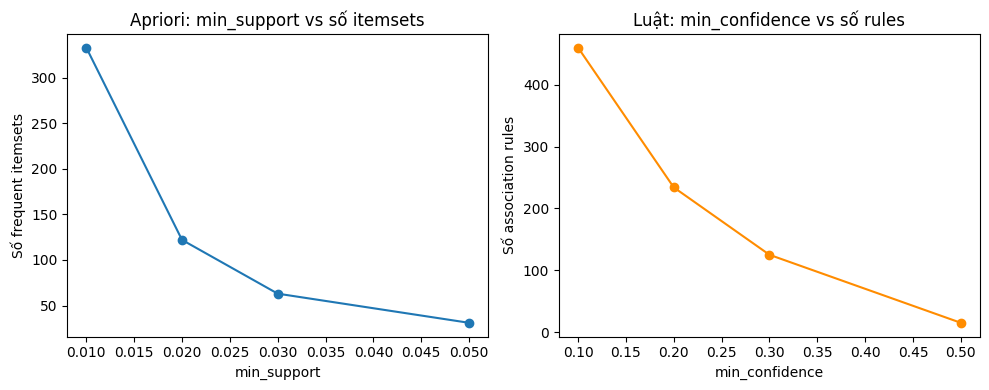

In [18]:
supports = [0.01, 0.02, 0.03, 0.05]
counts_itemsets = []
for s in supports:
    itemsets = mlxtend_apriori(df, min_support=s, use_colnames=True)
    counts_itemsets.append(len(itemsets))

print("min_support -> số frequent itemsets (Apriori):")
for s, c in zip(supports, counts_itemsets):
    print(f"  {s}: {c}")

conf_thresholds = [0.1, 0.2, 0.3, 0.5]
fp_for_rules = fpgrowth(df, min_support=0.01, use_colnames=True)
counts_rules = []
for mc in conf_thresholds:
    r = association_rules(fp_for_rules, metric="confidence", min_threshold=mc)
    counts_rules.append(len(r))

print("\nmin_confidence -> số luật (FP-Growth @ min_support=0.01):")
for mc, c in zip(conf_thresholds, counts_rules):
    print(f"  {mc}: {c}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(supports, counts_itemsets, marker="o")
axes[0].set_title("Apriori: min_support vs số itemsets")
axes[0].set_xlabel("min_support")
axes[0].set_ylabel("Số frequent itemsets")

axes[1].plot(conf_thresholds, counts_rules, marker="o", color="darkorange")
axes[1].set_title("Luật: min_confidence vs số rules")
axes[1].set_xlabel("min_confidence")
axes[1].set_ylabel("Số association rules")
plt.tight_layout()
plt.show()

## Bài tập 2: Online Retail.xlsx

Install and import libraries

In [26]:
%pip install -q openpyxl mlxtend pandas scikit-learn numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from itertools import combinations
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori as mlxtend_apriori, fpgrowth, association_rules
from pathlib import Path

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Câu 1: Đọc file online_retail.xlsx và hiển thị thông tin cơ bản của dataset. Làm sạch dữ liệu: Loại bỏ các dòng có CustomerID bị thiếu và chỉ giữ các dòng có: Quantity > 0, UnitPrice > 0

In [27]:
## Đọc file
RETAIL_PATH = "Online Retail.xlsx"
df_retail = pd.read_excel(RETAIL_PATH, engine="openpyxl")

## Hiển thị thông tin cơ bản của dataset
print("=== info ===")
df_retail.info()
print("\n=== describe ===")
display(df_retail.describe(include="all"))

## Làm sạch dữ liệu
df_retail_clean = df_retail.dropna(subset=["CustomerID"]).copy()
df_retail_clean = df_retail_clean[
    (df_retail_clean["Quantity"] > 0) & (df_retail_clean["UnitPrice"] > 0)
]
print(f"\nSố dòng sau làm sạch: {len(df_retail_clean)}")
df_retail_clean.head()

=== info ===
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB

=== describe ===


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN



Số dòng sau làm sạch: 397884


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Câu 2: Chuyển dữ liệu về dạng transaction list, trong đó mỗi InvoiceNo là một transaction.

In [29]:
transactions_rt = (
    df_retail_clean.groupby("InvoiceNo")["StockCode"]
    .apply(lambda s: list(dict.fromkeys(s.astype(str))))
    .tolist()
)
print(f"Số giao dịch: {len(transactions_rt)}")
print("Ví dụ 3 giao dịch:", transactions_rt[:3])

Số giao dịch: 18532
Ví dụ 3 giao dịch: [['85123A', '71053', '84406B', '84029G', '84029E', '22752', '21730'], ['22633', '22632'], ['84879', '22745', '22748', '22749', '22310', '84969', '22623', '22622', '21754', '21755', '21777', '48187']]


Câu 3: Viết hàm tính support của một itemset.

In [31]:
def itemset_support(itemset, transactions):
    """Support(X) = số giao dịch chứa X / tổng số giao dịch."""
    n = len(transactions)
    if n == 0:
        return 0.0
    s = set(itemset)
    cnt = sum(1 for t in transactions if s.issubset(set(t)))
    return cnt / n

Câu 4: Tính support của một số item cụ thể.

In [32]:
one = ["85123A"]
two = ["85123A", "71053"]
print("Support 1-itemset", one, ":", itemset_support(one, transactions_rt))
print("Support 2-itemset", two, ":", itemset_support(two, transactions_rt))

Support 1-itemset ['85123A'] : 0.1067342974314699
Support 2-itemset ['85123A', '71053'] : 0.004154975178070365


Câu 5: Tìm frequent 1-itemsets với `min_support = 0.02`.

In [33]:
min_sup_rt = 0.02
all_items_rt = sorted({x for t in transactions_rt for x in t})
sup1_rt = {it: itemset_support([it], transactions_rt) for it in all_items_rt}
L1_rt = {it: sup for it, sup in sup1_rt.items() if sup >= min_sup_rt}
print(f"|L1| = {len(L1_rt)} (min_support={min_sup_rt})")

|L1| = 209 (min_support=0.02)


Câu 6: Sinh candidate 2-itemsets từ frequent 1-itemsets.

In [34]:
items_L1_rt = list(L1_rt.keys())
C2_rt = list(combinations(items_L1_rt, 2))
print(f"|C2| = {len(C2_rt)}")

|C2| = 21736


Câu 7: Tính support và tìm frequent 2-itemsets.

In [35]:
sup2_rt = {pair: itemset_support(pair, transactions_rt) for pair in C2_rt}
L2_rt = {pair: s for pair, s in sup2_rt.items() if s >= min_sup_rt}
print(f"|L2| = {len(L2_rt)}")

|L2| = 41


Câu 8: Viết hàm tính confidence của luật: `𝑋 → 𝑌`. Với X là 85123A và Y là 71053.

In [36]:
def rule_confidence(antecedent, consequent, transactions):
    X, Y = set(antecedent), set(consequent)
    sup_xy = itemset_support(list(X | Y), transactions)
    sup_x = itemset_support(list(X), transactions)
    if sup_x == 0:
        return float("nan")
    return sup_xy / sup_x


conf_851_710 = rule_confidence(["85123A"], ["71053"], transactions_rt)
print("confidence(85123A → 71053) =", conf_851_710)

confidence(85123A → 71053) = 0.038928210313447925


Câu 9: Không sử dụng thư viện, cài đặt thuật toán Apriori để tìm tất cả frequent itemsets.

In [37]:
L_all_retail = apriori(transactions_rt, min_sup_rt, verbose=False)
for i, layer in enumerate(L_all_retail):
    print(f"L{i + 1}: {len(layer)} itemsets")

L1: 209 itemsets
L2: 41 itemsets
L3: 1 itemsets


Câu 10: Chuyển transaction data sang dạng one-hot encoding.

In [38]:
te_rt = TransactionEncoder()
arr_rt = te_rt.fit(transactions_rt).transform(transactions_rt)
df_rt_ohe = pd.DataFrame(arr_rt, columns=te_rt.columns_)
print(df_rt_ohe.shape)
df_rt_ohe.head()

(18532, 3665)


,10002,10080,10120,10123C,10124A,10124G,10125,10133,10135,11001,...,90214V,90214W,90214Y,90214Z,BANK CHARGES,C2,DOT,M,PADS,POST
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Câu 11: Sử dụng thư viện mlxtend để tìm các tập phổ biến bằng thuật toán Apriori.

In [39]:
fi_ap_retail = mlxtend_apriori(df_rt_ohe, min_support=min_sup_rt, use_colnames=True)
print(fi_ap_retail.head())
print("Số itemsets:", len(fi_ap_retail))

    support             itemsets
0  0.020397  frozenset({15056N})
1  0.031081   frozenset({20685})
2  0.026549   frozenset({20712})
3  0.022178   frozenset({20713})
4  0.020721   frozenset({20718})
Số itemsets: 251


Câu 12: Sử dụng thư viện mlxtend để tìm các tập phổ biến bằng thuật toán FP-Growth.

In [ ]:
## Đã import thư viện mlxtend ở đầu BT2
fi_fp_retail = fpgrowth(df_rt_ohe, min_support=min_sup_rt, use_colnames=True)
print(fi_fp_retail.head())
print("Số itemsets:", len(fi_fp_retail))

    support             itemsets
0  0.106734  frozenset({85123A})
1  0.023797   frozenset({22633})
2  0.074196   frozenset({84879})
3  0.037287   frozenset({21754})
4  0.029948   frozenset({21755})
Số itemsets: 251


Câu 13: Tạo các association rules từ frequent itemsets tìm được ở câu 11 (Apriori).

In [42]:
rules_retail = association_rules(
    fi_ap_retail, metric="confidence", min_threshold=0.01
)
print(f"Số luật (min_confidence=0.01): {len(rules_retail)}")
rules_retail.head()

Số luật (min_confidence=0.01): 88


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({20725}),frozenset({20726}),0.069555,0.044248,0.023365,0.335919,7.591777,1.0,0.020287,1.439211,0.933187,0.258353,0.305175,0.431984
1,frozenset({20726}),frozenset({20725}),0.044248,0.069555,0.023365,0.528049,7.591777,1.0,0.020287,1.971485,0.908477,0.258353,0.492768,0.431984
2,frozenset({20727}),frozenset({20725}),0.056767,0.069555,0.027898,0.491445,7.065521,1.0,0.023949,1.829585,0.910133,0.283443,0.453428,0.446265
3,frozenset({20725}),frozenset({20727}),0.069555,0.056767,0.027898,0.401086,7.065521,1.0,0.023949,1.574906,0.922642,0.283443,0.365042,0.446265
4,frozenset({20728}),frozenset({20725}),0.052126,0.069555,0.024768,0.475155,6.831325,1.0,0.021142,1.772800,0.900558,0.255568,0.435921,0.415623


Câu 14: Lọc các luật mạnh với: `confidence ≥ 0.7` và `lift ≥ 1.2`

In [43]:
strong_rules = rules_retail[
    (rules_retail["confidence"] >= 0.7) & (rules_retail["lift"] >= 1.2)
]
print(f"Số luật mạnh: {len(strong_rules)}")
strong_rules.head(20)

Số luật mạnh: 8


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
56,frozenset({22698}),frozenset({22697}),0.030002,0.037287,0.024822,0.827338,22.188466,1.0,0.023703,5.575714,0.984468,0.584498,0.820651,0.746520
59,frozenset({22697}),frozenset({22699}),0.037287,0.042251,0.029193,0.782923,18.530185,1.0,0.027617,4.412029,0.982675,0.579850,0.773347,0.736928
60,frozenset({22698}),frozenset({22699}),0.030002,0.042251,0.023527,0.784173,18.559754,1.0,0.022259,4.437569,0.975384,0.482835,0.774651,0.670503
76,frozenset({23300}),frozenset({23301}),0.034265,0.040794,0.024984,0.729134,17.873424,1.0,0.023586,3.541254,0.977547,0.498922,0.717614,0.670784
82,"frozenset({22698, 22699})",frozenset({22697}),0.023527,0.037287,0.021045,0.894495,23.989564,1.0,0.020167,9.124846,0.981405,0.529172,0.890409,0.729447
83,"frozenset({22698, 22697})",frozenset({22699}),0.024822,0.042251,0.021045,0.847826,20.066300,1.0,0.019996,6.293778,0.974350,0.457210,0.841113,0.672955
84,"frozenset({22699, 22697})",frozenset({22698}),0.029193,0.030002,0.021045,0.720887,24.027846,1.0,0.020169,3.475290,0.987201,0.551627,0.712254,0.711163
85,frozenset({22698}),"frozenset({22699, 22697})",0.030002,0.029193,0.021045,0.701439,24.027846,1.0,0.020169,3.251619,0.988024,0.551627,0.692461,0.711163


Câu 15: Vẽ biểu đồ thể hiện `min_support` từ 0.01 đến 0.1 (bước nhảy = 0.01) và số lượng itemsets tương ứng

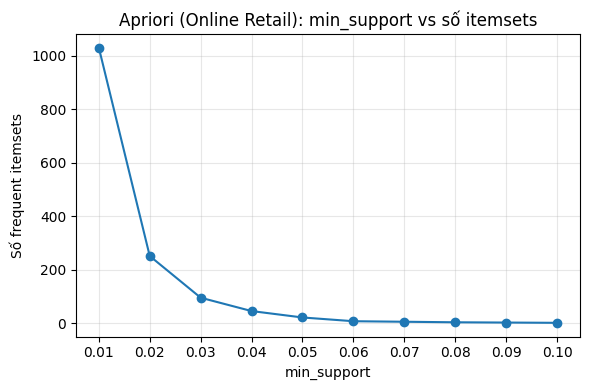

In [45]:
sup_grid = np.arange(0.01, 0.101, 0.01)
n_itemsets = []
for s in sup_grid:
    fi = mlxtend_apriori(df_rt_ohe, min_support=float(s), use_colnames=True)
    n_itemsets.append(len(fi))

plt.figure(figsize=(6, 4))
plt.plot(sup_grid, n_itemsets, marker="o")
plt.xlabel("min_support")
plt.ylabel("Số frequent itemsets")
plt.title("Apriori (Online Retail): min_support vs số itemsets")
plt.xticks(sup_grid)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()